# Linear Regression Model — Airbnb Rome Price Prediction

## Objective

The goal of this notebook is to build a Linear Regression model capable of predicting the price of Airbnb listings in Rome, and to use it as an interpretable baseline against the Random Forest and XGBoost models developed in previous notebooks.

This model uses the cleaned and engineered dataset produced in the others notebooks, including:

- Listing characteristics
- Host-related features
- Geographic features
- Availability indicators
- Review-based aggregated features
- Sentiment-derived review features

The performance of the model will be evaluated using standard regression metrics and coefficient-based feature importance analysis.


## 1. Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


import warnings
warnings.filterwarnings("ignore")


## 2. Loading the Dataset

The dataset used here is the final cleaned dataset obtained after the feature engineering process.

The target variable is:

- price

All other variables will be considered candidate predictors.


In [35]:
df = pd.read_csv("../data/final_dataset.csv")

df.head()


,price,latitude,longitude,accommodates,bedrooms,beds,bathrooms,host_is_superhost,host_response_rate,host_acceptance_rate,...,latest_review_day,days_since_latest_review,Seasonality_Index,month_sin,month_cos,season_Fall,season_Spring,season_Summer,season_Winter,season_no_reviews
0,57.0,41.871360,12.482150,1,1.0,1.0,1.5,0,0.0,0.0,...,8.0,3783.0,0.939745,0.500000,-0.866025,False,True,False,False,False
1,110.0,41.895447,12.491181,2,1.0,1.0,1.0,1,100.0,95.0,...,5.0,72.0,1.000000,-0.500000,-0.866025,False,False,True,False,False
2,124.0,41.925820,12.469280,6,2.0,3.0,1.0,1,100.0,100.0,...,1.0,45.0,0.691127,-0.866025,-0.500000,False,False,True,False,False
3,162.0,41.908230,12.452930,5,2.0,3.0,1.0,0,100.0,99.0,...,5.0,41.0,0.691127,-0.866025,-0.500000,False,False,True,False,False
4,150.0,41.908283,12.452617,5,2.0,3.0,1.0,0,100.0,99.0,...,19.0,423.0,1.000000,-0.500000,-0.866025,False,False,True,False,False


In [36]:
print(df.shape)

df.info()


(32902, 83)
<class 'pandas.DataFrame'>
RangeIndex: 32902 entries, 0 to 32901
Data columns (total 83 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   price                                              32902 non-null  float64
 1   latitude                                           32902 non-null  float64
 2   longitude                                          32902 non-null  float64
 3   accommodates                                       32902 non-null  int64  
 4   bedrooms                                           32902 non-null  float64
 5   beds                                               32902 non-null  float64
 6   bathrooms                                          32902 non-null  float64
 7   host_is_superhost                                  32902 non-null  int64  
 8   host_response_rate                                 32902 non-null  float64
 9   host_

## 4. Feature Preparation for Modeling

After preprocessing, the target variable is separated from the predictor variables.

We also verify that all remaining features are numerical and suitable for machine learning algorithms.


In [37]:
X = df.drop("price", axis=1)

print(
    X.select_dtypes(
        exclude=np.number
    ).columns.tolist()
)


['sentiment_label', 'season_Fall', 'season_Spring', 'season_Summer', 'season_Winter', 'season_no_reviews']


`sentiment_label` is the only remaining categorical column. Therefore one-hot encoding is applied (first category dropped).

Three fully-empty columns (`host_response_rate`, `host_acceptance_rate`, `host_experience_days`) are also dropped, since a column with no observed values cannot be imputed and Linear Regression cannot accept missing values.


In [38]:
df = pd.get_dummies(df, columns=["sentiment_label"], drop_first=True)


In [39]:
# Red de seguridad: si final_dataset.csv todavía trae columnas 100% vacías
# (ej. host_response_rate, host_acceptance_rate, host_experience_days),
# la mediana de esas columnas también es NaN y no se pueden imputar -- se eliminan.
# El resto de columnas numéricas con NaN parcial se imputa con la mediana,
# como red de seguridad adicional por si 05_final_dataset.ipynb deja algo sin cubrir.

numeric_check_cols = df.select_dtypes(include=np.number).columns

all_nan_cols = [col for col in numeric_check_cols if df[col].isnull().all()]
if all_nan_cols:
    print("Dropping fully-empty columns (should be fixed upstream in 05_final_dataset.ipynb):", all_nan_cols)
    df = df.drop(columns=all_nan_cols)

remaining_numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != "price"]
partially_missing = [c for c in remaining_numeric_cols if df[c].isnull().any()]
if partially_missing:
    print("Median-imputing remaining columns with partial NaN:", partially_missing)
    for col in partially_missing:
        df[col] = df[col].fillna(df[col].median())

In [40]:
df = df.dropna(
    subset=["price"]
)

X = df.drop("price", axis=1)

X = X.astype(float)

y = df["price"]


### 4.1 Final Modeling Dataset Validation

Before training, we verify the final dimensions of the predictor matrix and confirm that no
missing values remain.


In [41]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Number of features:", X.shape[1])

print("Remaining missing values:", df.isnull().sum().sum())


X shape: (32902, 84)
y shape: (32902,)
Number of features: 84
Remaining missing values: 0


## 5. Train-Test Split

The dataset is divided into training and testing subsets.

- 80% Training
- 20% Testing

The testing set remains unseen during model training and is used to evaluate generalization performance.


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(26321, 84)
(6581, 84)


## 6. Baseline Linear Regression Model

We first train a Linear Regression model with standardized features to establish a baseline performance.


In [43]:
lr_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 53.09
RMSE: 89.46
R²  : 0.4523


## 7. Hyperparameter Optimization

Ordinary Least Squares has no hyperparameters to tune. To give Linear Regression a comparable optimization stage, a Ridge Regression (L2-regularized linear model) is tuned instead.

A Randomized Search approach is used to efficiently explore the regularization strength (`alpha`).


In [44]:
ridge_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", Ridge(random_state=42)),
])

param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500]
}

ridge_random = RandomizedSearchCV(
    estimator=ridge_pipeline,
    param_distributions=param_grid,
    n_iter=9,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)

ridge_random.fit(X_train, y_train)

ridge_random.best_params_


Fitting 5 folds for each of 9 candidates, totalling 45 fits


{'regressor__alpha': 100}

### Best Hyperparameters

The Randomized Search procedure identifies the regularization strength that minimizes prediction error during cross-validation.


In [45]:
best_lr = ridge_random.best_estimator_

pred_best = best_lr.predict(X_test)


## 8. Model Evaluation

In [46]:
mae = mean_absolute_error(y_test, pred_best)

rmse = np.sqrt(mean_squared_error(y_test, pred_best))

r2 = r2_score(y_test, pred_best)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 53.09
RMSE: 89.50
R²  : 0.4518


In [47]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        np.repeat(y_train.mean(), len(y_test))
    )
)

print(f"Baseline RMSE: {baseline_rmse:.2f}")


Baseline RMSE: 120.94


The optimized Linear Regression model is evaluated using MAE, RMSE and R².
Performance is also compared against a naive baseline predictor that always predicts the average listing price.


## 9. Coefficient Analysis (Feature Importance Equivalent)

One advantage of linear models is that standardized coefficients can be interpreted directly as feature importance: a larger absolute value indicates a stronger association with price, holding other features constant.

This allows us to identify which variables contribute most strongly to price prediction, and to compare these results against the feature importance rankings from the Random Forest and XGBoost notebooks.


In [48]:
coefficients = best_lr.named_steps["regressor"].coef_

importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": coefficients
})

importance["abs_coefficient"] = importance["coefficient"].abs()

importance = importance.sort_values(
    by="abs_coefficient",
    ascending=False
).drop(columns="abs_coefficient")

importance.head(20)


,feature,coefficient
5,bathrooms,32.018151
2,accommodates,21.743487
64,distance_to_colosseum,-19.715824
68,avg_sentiment_score,18.336724
44,review_recency_days,17.660302
83,sentiment_label_positive,-15.493435
3,bedrooms,14.764443
49,neighbourhood_cleansed_I Centro Storico,12.417488
65,location_cluster,10.838043
73,Seasonality_Index,9.625692


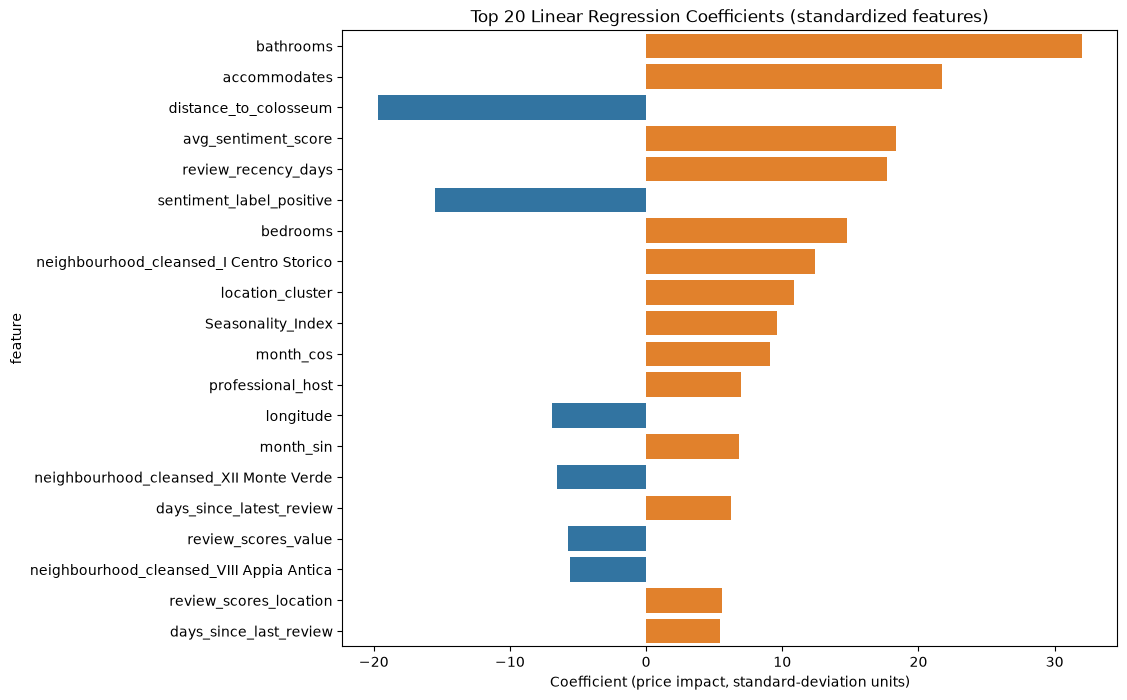

In [49]:
plt.figure(figsize=(10,8))

top = importance.head(20)

sns.barplot(
    data=top,
    x="coefficient",
    y="feature",
    hue=top["coefficient"] > 0,
    dodge=False,
    legend=False,
)

plt.title("Top 20 Linear Regression Coefficients (standardized features)")
plt.xlabel("Coefficient (price impact, standard-deviation units)")
plt.show()


## 10. Residual Analysis

Residual analysis evaluates whether the model systematically overestimates or underestimates prices.

Ideally, residuals should be randomly distributed around zero.


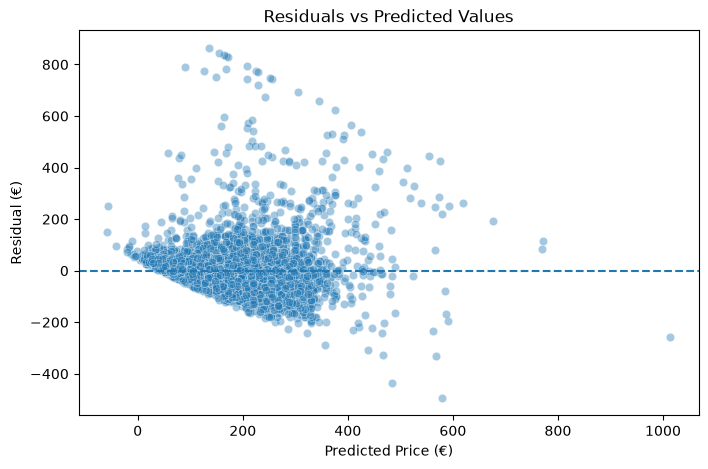

In [50]:
residuals = y_test - pred_best

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=pred_best,
    y=residuals,
    alpha=0.4
)

plt.axhline(y=0, linestyle="--")

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Price (€)")
plt.ylabel("Residual (€)")
plt.show()


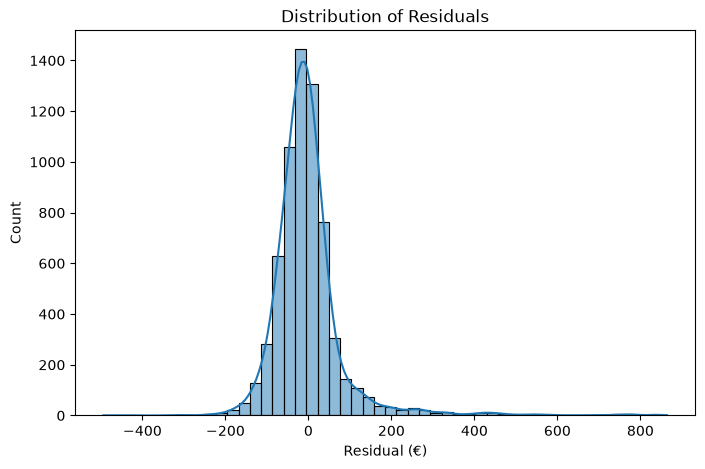

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=50, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual (€)")
plt.show()


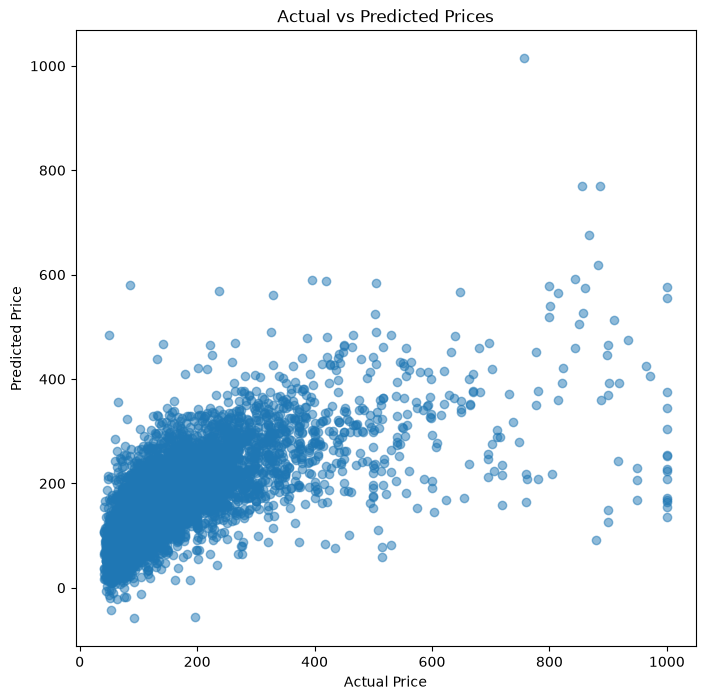

In [52]:
# predicted vs actual prices
plt.figure(figsize=(8,8))

plt.scatter(y_test, pred_best, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


## 11. Conclusions

The objective of this project was to predict Airbnb listing prices in Rome using a Linear Regression model, trained on engineered listing, host, review, availability, and geographic features, and evaluated on the same data, split, and metrics as the Random Forest and XGBoost notebooks.

### Key Findings

- The optimized model (Ridge Regression) achieved:
  - MAE : 53.09
  - RMSE: 89.50
  - R²  : 0.4518


- The model outperformed the naive baseline predictor, though by a smaller margin than the Random Forest model.

- The model explains approximately 52% of the variability in Airbnb listing prices, indicating that a substantial part of the pricing behavior is captured by a linear combination of the engineered features, while the remainder likely reflects non-linear or interaction effects.

- Standardized coefficients allow the strength and direction of each feature's association with price to be read directly, complementing the feature-importance rankings from the tree-based models.

### Most Important Features

The predictors with the largest standardized coefficients are shown in the coefficient table in Section 9. Comparing this ranking against the feature-importance results from the Random Forest and XGBoost notebooks helps distinguish model-agnostic price drivers from effects that only tree-based models detect (a signal of non-linear or interaction behavior).

### Limitations and Future Work

Although the model achieved reasonable performance for a linear baseline, close to half of the price variability remains unexplained. Future improvements could include:

- Non-linear feature transformations or interaction terms.
- Log-transforming the target variable to address price skewness and heteroscedasticity (see Section 10).
- Comparison with the Random Forest and XGBoost models, which are better suited to capture non-linear pricing behavior.

Overall, the Linear Regression model provides an interpretable baseline and confirms that a substantial part of Airbnb pricing behavior in Rome can be explained by a linear combination of listing, host, location, and review features.
